# Estimating Uncertainty in the Black Hole Mass–Velocity Dispersion Relation

:::{admonition} [Yasmeen Asali](https://orcid.org/0000-0002-8320-2198), [Imad Pasha](https://orcid.org/0000-0002-7075-9931), [William Cerny](https://orcid.org/0000-0003-1697-7062), [Sebastian Monzon](https://orcid.org/0000-0002-9986-4604) (Yale University)
:class: Author

*Description*: Estimate the uncertainty on a linear fit to the M-$\sigma$ relation using bootstrap resampling. This exercise introduces statistical resampling and uncertainty quantification using real data and linear regression.

*Intended Audience*: Beginner Undergraduate

*Tags*: `linear-regression`, `model-fitting`

*Requirements*: `numpy`, `matplotlib`, `pandas` ([requirements.txt](./requirements.txt))

*Last Updated: August 9, 2024*
:::

:::{admonition} Learning Objectives
:class: learningobjective 

1. Understand and implement bootstrap resampling to assess model uncertainty.
2. Practice using numpy to generate random samples.
3. Fit and interpret linear models. 
4. Visualize parameter distributions to quantify fit variability.
:::


## Introduction

The M-sigma relation, also known as the black hole mass-velocity dispersion relation, is an empirical correlation observed between the mass of supermassive black holes ($M_{bh}$) at the centers of galaxies and the velocity dispersion ($\sigma$) of stars in the bulges of those galaxies. This relationship suggests that there is a tight connection between the properties of galaxies and the central black holes they host. Specifically, galaxies with larger velocity dispersions tend to harbor more massive black holes at their centers.

The M-$\sigma$ relation has profound implications for our understanding of galaxy formation and evolution, as well as the co-evolution of galaxies and their central black holes. It provides valuable insights into the mechanisms governing the growth and regulation of supermassive black holes, the role of feedback processes in galaxy evolution, and the relationship between the properties of galactic bulges and their central black holes.

### Loading the data

We'll begin by loading some measurements of black hole mass (`M_bh`) and bulge velocity dispersion (`sigma`) for a set of nearby galaxies. 

:::{exercise}
:class: dropdown 

Use the `pandas` library to load the `m-sigma.txt` file into a `DataFrame` (download [here](./m-sigma.txt)); it should read in with headings automatically.

:::

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('m-sigma.txt')
df.head()

,Galaxy,M_bh,sigma,sigma_err,M_bh_err
0,MW,2950000.0,100,20,350000.0
1,I1459,460000000.0,312,41,280000000.0
2,N221,3900000.0,76,10,900000.0
3,N3115,920000000.0,278,36,300000000.0
4,N3379,135000000.0,201,26,73000000.0


The relation is typically plotted with the black hole masses in `log` form. Let's add two columns to 

::::{admonition} Linear Regression for the M-sigma Relation
:class: tip

We will apply the concept of linear regression to analyze the M-sigma relation using observational data. We have provided a dataset containing measurements of black hole masses (M_bh), velocity dispersions (sigma), and their associated uncertainties. Your task is to perform linear regression to fit both the black hole mass as a function of velocity dispersion (M_bh vs. sigma) and velocity dispersion as a function of black hole mass (sigma vs. M_bh).

1. **Prepare the Data**: Inspect the first few rows of the Pandas dataframe to familiarize yourself with the structure of the data. The M-sigma relation is usually in log-log space, so you will need to convert your data to logspace. 

2. **Plot the Data**: Create a scatter plot of the log of the black hole mass (log(M_bh)) against velocity dispersion (sigma), with error bars representing the uncertainties in both quantities.

3. **Perform Linear Regression**:
   - Fit a linear regression model to the data, treating M_bh as the dependent variable (y) and sigma as the independent variable (x) and incorporate the errors on sigma in the fit
   - Fit another linear regression model, treating sigma as the dependent variable (y) and M_bh as the independent variable (x) and incorporate the errors on M_bh in the fit.
     :::{hint} Hint: Incorporating Errors
     :class: dropdown
     Look into the weights keyword argument for `np.polyfit` to figure out how to incorporate errors. 
     :::

4. **Visualize the Results**: Plot the regression lines along with the data points to observe how well they fit the M-sigma relation. Compare the slopes and intercepts of the regression lines for both fits. 

:::: 

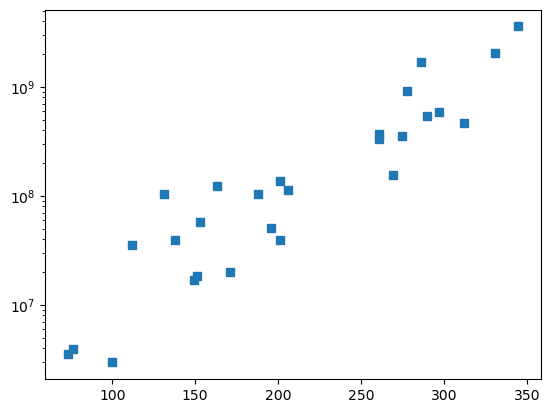

In [2]:
plt.plot(df.sigma,df.M_bh,'s')
plt.yscale('log')

Now, we want to add errors to the above plot! To do this, we will need to propagate the error when taking the logarithm (base 10). 

$$
\sigma_{\log_{10}(x)} = \frac{1}{\ln(10) \cdot x} \cdot \sigma_x
$$

This will give you the uncertainty on the logarithm of the black hole mass. 

In [ ]:
log_BH = np.log10(df.M_bh)
BH_err = df.M_bh_err / (df.M_bh * np.log(10))

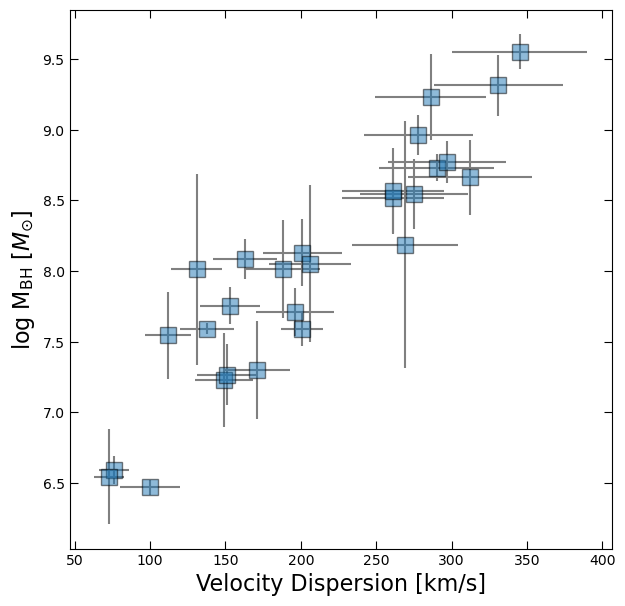

In [6]:
fig, ax = plt.subplots(figsize=(7,7))
ax.errorbar(df.sigma, log_BH, yerr=BH_err, xerr=df.sigma_err, fmt='None', color='gray')
ax.plot(df.sigma, log_BH, 's', color='C0', ms=12, alpha=0.5, mec='k')
ax.set_xlabel('Velocity Dispersion [km/s]', fontsize=16)
ax.tick_params(which='both', top=True, right=True, direction='in', length=6)
ax.set_ylabel(r'log M$_{\rm BH}$ [$M_{\odot}$]', fontsize=16);

## Linear Regression:

Linear regression just means "let's fit a line"! It's a statistical method used to model the relationship between a dependent variable (often denoted as 'y') and one or more independent variables (often denoted as 'x'). It assumes that the relationship between the variables can be described by a linear equation, such as a straight line in the case of simple linear regression. Like an inference task, the goal of linear regression is to find the best-fitting line that minimizes the differences between the observed values and the values predicted by the model.

For the simpliest case of a straight line, aka a first order polynomial, we can describe our model using two parameters: **slope** and **intercept**. 

### How can we implement this in python? 

`np.polyfit` is a function in NumPy used for polynomial regression, which fits a polynomial curve to a set of data points. In the context of linear regression, `np.polyfit` fits a polynomial of degree 1 (a straight line) to the given data points by minimizing the sum of squared errors between the observed and predicted values. This function returns the coefficients of the polynomial that best fits the data, allowing us to determine the slope and intercept of the regression line.

Last time, we showed you how you could use `np.polyfit` to fit a line. The code we used to do this looked like:
```
# Fit a straight line (polynomial of degree 1) to the data
coefficients = np.polyfit(x, y, deg=1)

# For a first order polynomial, there are two coefficients
# Extract the slope (m) and intercept (b) from the coefficients
slope, intercept = coefficients 

# Generate points along the fitted line for plotting
x_fit = np.linspace(min(x), max(x), 100)
y_fit = slope * x_fit + intercept
```

We can do this more efficiently using the `np.polyval` function to generate `y_fit` without needing to write out the equation y = mx + b. 

In [4]:
coefficients = np.polyfit(df.sigma,log_BH,deg=1,w=1/BH_err)
x_fit = np.linspace(50,400,100)
y_fit = np.polyval(coefficients, x_fit)

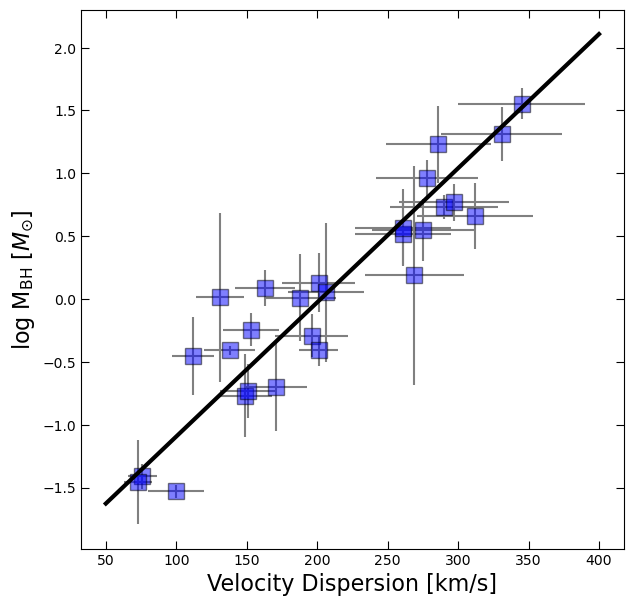

In [5]:
fig, ax = plt.subplots(figsize=(7,7))
ax.errorbar(df.sigma, log_BH, yerr=BH_err, xerr=df.sigma_err, fmt='None', color='gray')
ax.plot(df.sigma, log_BH, 's', color='blue', ms=12, alpha=0.5, mec='k')
ax.plot(x_fit, y_fit, 'k', lw=3)
ax.set_xlabel('Velocity Dispersion [km/s]', fontsize=16)
ax.tick_params(which='both', top=True, right=True, direction='in', length=6)
ax.set_ylabel(r'log M$_{\rm BH}$ [$M_{\odot}$]', fontsize=16);

### Fitting x(y) 

We also discussed how linear least squares is only accounting for the uncertainties in the independent variable (here our $y$-axis). But both quantities being plotted had major uncertainties, so we asked you to fit x(y) as well, using the errors on x instead of y. The solution to that attempt is below.

In [6]:
coeff2 = np.polyfit(log_BH,df.sigma,deg=1,w=1/df.sigma_err)
in_masses = np.linspace(-1.5,2,100)
out_velocities = np.polyval(coeff2,in_masses)

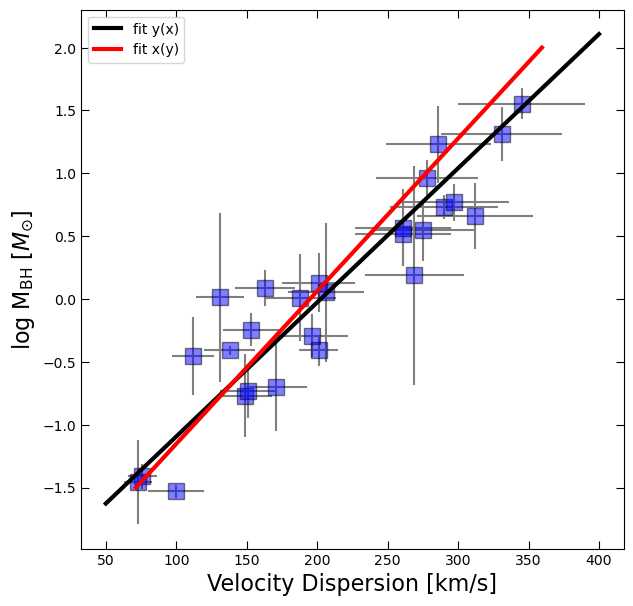

In [7]:
fig, ax = plt.subplots(figsize=(7,7))
ax.errorbar(df.sigma, log_BH, yerr=BH_err, xerr=df.sigma_err, fmt='None', color='gray')
ax.plot(df.sigma, log_BH, 's', color='blue', ms=12, alpha=0.5, mec='k')
ax.plot(x_fit, y_fit, 'k', lw=3, label='fit y(x)')
ax.plot(out_velocities, in_masses, 'r', lw=3, label='fit x(y)')
ax.set_xlabel('Velocity Dispersion [km/s]', fontsize=16)
ax.tick_params(which='both', top=True, right=True, direction='in', length=6)
ax.legend()
ax.set_ylabel(r'log M$_{\rm BH}$ [$M_{\odot}$]', fontsize=16);

## Bootstrap Resampling 

Bootstrapping is a resampling technique used in statistics to estimate the sampling distribution of a statistic by repeatedly sampling with replacement from the observed data. It is particularly useful when the underlying population distribution is unknown or difficult to model. 

1. Sample Creation: Bootstrapping starts with the creation of multiple bootstrap samples by randomly selecting observations from the original dataset with replacement. This means that each observation in the original dataset has the same chance of being selected for each bootstrap sample, and some observations may be selected multiple times while others may not be selected at all.
2. Statistical Estimation: After creating the bootstrap samples, the statistic of interest (e.g., mean, median, standard deviation, regression coefficient) is calculated for each bootstrap sample. This results in a distribution of the statistic across the bootstrap samples, known as the bootstrap distribution. In our case, this would be fitting our line to the data and seeing how much the paramters (slope and intercept) change for each fit. Now, we have some way of expressing uncertainty in our fitted parameters! 

The goal for today is to use bootstrapping to estimate the uncertainty on our fit for the M-sigma relation! 

![bootstrapping_image](bootstrap_resampling.png)

::::{admonition} Exercise 1: Bootstrap Resampling for our Linear Fit to the M-sigma Relation
:class: tip

Using your code from Monday, start by loading the data and fitting a linear model. 

1. **Perform Bootstrap Resampling:** To do this, you will re-fit the data many times after creating subsamples of
randomly drawn datasets (**with replacement**) from our actual data. In general, you can choose the number of bootstrap samples to generate based on computational resources and desired precision. For this case, you can start by generating ~500 bootstrap samples. For each bootstrap iteration: 
    - Generate a bootstrap sample from the observed data by randomly sampling with replacement N points from the data where N is the length of the data. Remember: you need to sample x, y, and yerr in some way that preserves the correct ordering (aka you can't take the black hole mass of one galaxy and the diserpersion of another galaxy!). There is a numpy function that can do this for you, so your first task is to search for this function!
    :::{hint} Hint
    :class: dropdown
    If you can't find it, the function you should use for this step is `np.random.choice`. Look at the documentation to figure out how to implement it. 
    :::
    - For each bootstrap sample, fit a linear model to the resampled data using the same procedure as before (first order polynomial with `np.polyfit`).
    - Append the coefficients (slope and intercept) of the linear fit for each bootstrap sample to a container of your choice (probably a list or array). 
2. **Visualize Results:** You should generate some plots to assess our bootstrapping results. 
    - First, add all 500 lines from your 500 bootstrap fits to your original M-sigma plot. Note: use a low `alpha` for your plots so the lines are semi-transparent! 
    - Plot histograms or density plots of the distributions of slopes and intercepts obtained from the bootstrap resampling. Additionally, overlay the slope and intercept derived from the original linear fit on the same plot for comparison.
3. **Evaluate and Interpret:** Examine the distribution of slopes and intercepts across the bootstrap samples to assess their variability and uncertainty. How well-constrained is our fit to the M-sigma relation on the basis of this data? 
:::: 